In [41]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [42]:
model = tf.keras.models.load_model('trained_set.keras')

In [43]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

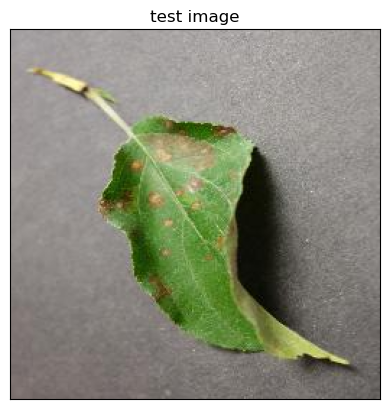

In [78]:
import cv2
image_path="test/test/AppleCedarRust3.JPG"
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("test image")
plt.xticks([])
plt.yticks([])
plt.show()

In [79]:
#testing model
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr=tf.keras.preprocessing.image.img_to_array(image)
input_arr=np.array([input_arr]) #convert single image to batch
print(input_arr.shape)

(1, 128, 128, 3)


In [80]:
prediction= model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 86ms/step


(array([[6.8021363e-05, 7.8188918e-05, 8.5376513e-01, 6.9476569e-05,
         1.0162146e-03, 7.0060056e-04, 7.5221838e-06, 1.7791643e-03,
         1.0312741e-04, 7.3153809e-05, 8.4318244e-06, 1.0544492e-03,
         1.2607450e-02, 1.1054612e-04, 4.4931448e-06, 1.2208085e-04,
         9.9304290e-03, 4.7487448e-04, 5.9103677e-03, 3.8016759e-04,
         2.1880920e-05, 3.3263830e-05, 2.6312817e-04, 1.5002517e-04,
         4.0591985e-06, 1.9034111e-05, 3.3419320e-04, 1.7726437e-05,
         5.9493419e-02, 1.2479555e-02, 2.5878295e-02, 1.6352864e-03,
         1.3633112e-04, 1.3994289e-04, 2.9749991e-04, 9.9712498e-03,
         5.6242570e-04, 2.9871115e-04]], dtype=float32),
 (1, 38))

In [81]:
result_index=np.argmax(prediction)
result_index

2

In [82]:
class_name=['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']


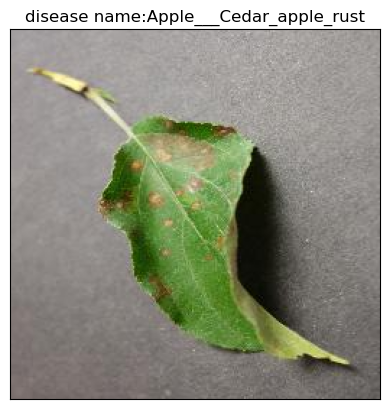

In [83]:
#disply resuly
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"disease name:{model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()


In [84]:
model_prediction

'Apple___Cedar_apple_rust'